In [1]:
# 1. IMPORTATION DES LIBRAIRIES (Unifié XGBoost / Random Forest)

# Manipulation de données
import numpy as np
import pandas as pd

# Outils Scikit-Learn (Validation, Pipelines, Métriques)
from sklearn.model_selection import KFold, cross_val_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Encodage et Optimisation
from category_encoders import TargetEncoder
import optuna

# Le Modèle (Adapté pour ton notebook)
from sklearn.ensemble import RandomForestRegressor

/home/awalther/anaconda3/envs/dataScience/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# 1. CHARGEMENT ET CONCATÉNATION

# Chargement des datasets d'entraînement et de test
train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

# Outliers à enlever selon la documentation
train_df = train_df[train_df["GrLivArea"] < 4000].reset_index(drop=True)
ntrain = len(train_df)
y_train_log = np.log1p(train_df["SalePrice"].copy())

all_data = pd.concat([train_df.drop(columns=["SalePrice"]), test_df], axis=0).reset_index(drop=True)

# Sauvegarde des IDs pour la soumission finale Kaggle, puis suppression
test_ids = test_df['Id'].copy()
all_data = all_data.drop(['Id'], axis=1)

print(f"Shape initiale all_data : {all_data.shape}")


# 2. NETTOYAGE GLOBAL SUR ALL_DATA

def apply_base_preprocessing(data):
    """Applique le nettoyage de base sur l'ensemble complet (Train + Test)"""
    df = data.copy()

    # 1. NA signifiant "Absence de l'équipement" -> Catégorie 'None'
    cols_none = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                 'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
                 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature', 'MasVnrType']
    for col in cols_none:
        if col in df.columns:
            df[col] = df[col].fillna('None')

    # 2. NA signifiant 0 pour les variables numériques
    cols_zero = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2',
                 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
    for col in cols_zero:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # 3. Imputation par la médiane globale pour la façade (LotFrontage)
    if 'LotFrontage' in df.columns:
        df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

    # 4. Imputation par le mode pour les vrais manquants
    cols_mode = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType', 'Functional', 'Utilities']
    for col in cols_mode:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0])

    # 5. Traitement Multicolinéarité
    cols_to_drop = ['GarageArea', 'TotRmsAbvGrd', 'GarageYrBlt']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    # 6. Feature Engineering
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['AgeAtSale'] = df['YrSold'] - df['YearBuilt']
    df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']

    return df

# Application du nettoyage
all_data_clean = apply_base_preprocessing(all_data)


# 3. SÉPARATION TRAIN / TEST

# On utilise ntrain pour retrouver nos données d'entraînement exactes
X_train_clean = all_data_clean.iloc[:ntrain].copy()
X_test_clean = all_data_clean.iloc[ntrain:].copy()

print(f"Shape X_train_clean : {X_train_clean.shape}")
print(f"Shape X_test_clean  : {X_test_clean.shape}")

Shape initiale all_data : (2915, 79)
Shape X_train_clean : (1456, 79)
Shape X_test_clean  : (1459, 79)


In [3]:
# 2 ENCODAGE AVANCÉ

class AdvancedCategoricalEngineer(BaseEstimator, TransformerMixin):
    """Transformateur Scikit-Learn pour encodage ordinal et Target Encoding"""
    def __init__(self, smoothing=10.0):
        self.smoothing = smoothing
        self.qual_mapping = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
        self.ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                             'HeatingQC', 'KitchenQual', 'FireplaceQu',
                             'GarageQual', 'GarageCond', 'PoolQC']
        self.te = None
        self.nominal_cols = None

    def fit(self, X, y):
        X_copy = X.copy()
        for col in self.ordinal_cols:
            if col in X_copy.columns:
                X_copy[col] = X_copy[col].map(self.qual_mapping).fillna(0)

        self.nominal_cols = X_copy.select_dtypes(include=['object']).columns.tolist()

        for col in self.nominal_cols:
            X_copy[col] = X_copy[col].astype(str).fillna('Missing')

        self.te = TargetEncoder(cols=self.nominal_cols, smoothing=self.smoothing)
        self.te.fit(X_copy[self.nominal_cols], y)
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col in self.ordinal_cols:
            if col in X_copy.columns:
                X_copy[col] = X_copy[col].map(self.qual_mapping).fillna(0)

        if self.nominal_cols:
            for col in self.nominal_cols:
                if col in X_copy.columns:
                    X_copy[col] = X_copy[col].astype(str).fillna('Missing')
            X_copy[self.nominal_cols] = self.te.transform(X_copy[self.nominal_cols])

        return X_copy


# 5. VALIDATION CROISÉE (Adaptée au Random Forest)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scores = []

print("\nDébut Validation Croisée (5-Fold) avec Random Forest...")

# Création du pipeline avec ton modèle RF
pipeline_m1 = Pipeline([
    ('encoder', AdvancedCategoricalEngineer(smoothing=10.0)),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_clean)):

    # Séparation locale pour ce pli
    X_tr, y_tr = X_train_clean.iloc[train_idx], y_train_log.iloc[train_idx]
    X_val, y_val = X_train_clean.iloc[val_idx], y_train_log.iloc[val_idx]

    # Entraînement et Prédiction
    pipeline_m1.fit(X_tr, y_tr)
    preds = pipeline_m1.predict(X_val)

    fold_rmse = np.sqrt(mean_squared_error(y_val, preds))
    rmse_scores.append(fold_rmse)
    print(f"Fold {fold + 1} | RMSE: {fold_rmse:.5f}")

print(f"\nRMSE Moyen (CV) RF : {np.mean(rmse_scores):.5f} (+/- {np.std(rmse_scores):.5f})")


Début Validation Croisée (5-Fold) avec Random Forest...
Fold 1 | RMSE: 0.13559
Fold 2 | RMSE: 0.12663
Fold 3 | RMSE: 0.13440
Fold 4 | RMSE: 0.14826
Fold 5 | RMSE: 0.11285

RMSE Moyen (CV) RF : 0.13155 (+/- 0.01164)


In [4]:
# 3. CONSTRUCTION DE LA PIPELINE HYBRIDE ET TUNING (M3 - Sur données unifiées)

from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from optuna.exceptions import TrialPruned

# Étape A : Le Filtre Lasso
# Il gardera uniquement les variables dont le coefficient n'a pas été réduit à 0.
feature_selector = SelectFromModel(LassoCV(cv=5, random_state=42))

# Étape B : Optimisation avec Optuna
def objective(trial):
    # Optuna suggère les hyperparamètres
    n_estimators = trial.suggest_int('n_estimators', 50, 500, step=50)
    max_depth = trial.suggest_int('max_depth', 5, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

    rf_model_trial = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    # NOUVELLE PIPELINE : On utilise l'encodeur de ton camarade
    pipeline_trial = Pipeline(steps=[
        ('encoder', AdvancedCategoricalEngineer(smoothing=10.0)),
        ('selector', feature_selector),
        ('rf', rf_model_trial)
    ])

    # Boucle CV manuelle sur les NOUVELLES variables
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_scores = []

    # On utilise X_train_clean et y_train_log
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_clean)):
        X_tr, X_val = X_train_clean.iloc[train_idx], X_train_clean.iloc[val_idx]
        y_tr, y_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]

        pipeline_trial.fit(X_tr, y_tr)
        preds = pipeline_trial.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, preds))
        neg_rmse = -rmse
        fold_scores.append(neg_rmse)

        # Report pour le pruner d'Optuna
        trial.report(neg_rmse, step=fold_idx)
        if trial.should_prune():
            raise TrialPruned()

    return float(np.mean(fold_scores))


# Étape C : Lancement de l'étude Optuna
print("Lancement de l'optimisation Optuna (recherche bayésienne intelligente + pruning)...")

sampler = TPESampler(seed=42)
pruner = MedianPruner(n_warmup_steps=5)

def stop_if_no_improvement_factory(patience=10):
    state = {'best_value': None, 'no_improve': 0}

    def _callback(study, trial):
        if state['best_value'] is None or study.best_value > state['best_value']:
            state['best_value'] = study.best_value
            state['no_improve'] = 0
        else:
            state['no_improve'] += 1

        if state['no_improve'] >= patience:
            print(f"Aucun progrès depuis {patience} essais — arrêt de l'étude Optuna.")
            study.stop()

    return _callback

early_stop_callback = stop_if_no_improvement_factory(patience=10)

study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    pruner=pruner
)

study.optimize(objective, n_trials=50, callbacks=[early_stop_callback], show_progress_bar=True)

print("-" * 50)
print("Optimisation terminée !")
print(f"Meilleur score CV (neg_rmse) : {study.best_value:.4f}")
print(f"Meilleurs hyperparamètres trouvés :\n{study.best_params}")
print("-" * 50)

# Étape D : Réentraîner le meilleur modèle
best_params = study.best_params
rf_best = RandomForestRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    max_features=best_params['max_features'],
    random_state=42,
    n_jobs=-1
)

best_m3_pipeline = Pipeline(steps=[
    ('encoder', AdvancedCategoricalEngineer(smoothing=10.0)),
    ('selector', feature_selector),
    ('rf', rf_best)
])

# Fit sur tout le nouveau train set
best_m3_pipeline.fit(X_train_clean, y_train_log)

# Évaluation sur le Train Set
y_pred_train = best_m3_pipeline.predict(X_train_clean)
rmse_train = np.sqrt(mean_squared_error(y_train_log, y_pred_train))
print(f"RMSE (Log) sur le Train Set : {rmse_train:.4f}")

[I 2026-05-28 15:44:20,021] A new study created in memory with name: no-name-606894ed-ed7f-49f3-a0a4-6fe55f077973


Lancement de l'optimisation Optuna (recherche bayésienne intelligente + pruning)...


Best trial: 0. Best value: -0.161868:   2%|▏         | 1/50 [00:01<01:10,  1.43s/it]

[I 2026-05-28 15:44:21,452] Trial 0 finished with value: -0.16186845091301072 and parameters: {'n_estimators': 200, 'max_depth': 48, 'min_samples_split': 15, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.16186845091301072.


Best trial: 0. Best value: -0.161868:   4%|▍         | 2/50 [00:02<01:01,  1.29s/it]

...

[I 2026-05-28 15:44:58,931] Trial 22 finished with value: -0.16072897656019405 and parameters: {'n_estimators': 150, 'max_depth': 31, 'min_samples_split': 8, 'max_features': 'log2'}. Best is trial 14 with value: -0.15935086116539235.


Best trial: 14. Best value: -0.159351:  48%|████▊     | 24/50 [00:40<00:42,  1.65s/it]

[I 2026-05-28 15:45:00,820] Trial 23 finished with value: -0.15976299490536103 and parameters: {'n_estimators': 300, 'max_depth': 22, 'min_samples_split': 4, 'max_features': 'log2'}. Best is trial 14 with value: -0.15935086116539235.


Best trial: 14. Best value: -0.159351:  50%|█████     | 25/50 [00:42<00:42,  1.70s/it]


[I 2026-05-28 15:45:02,542] Trial 24 finished with value: -0.15982966664794673 and parameters: {'n_estimators': 250, 'max_depth': 28, 'min_samples_split': 4, 'max_features': 'log2'}. Best is trial 14 with value: -0.15935086116539235.
Aucun progrès depuis 10 essais — arrêt de l'étude Optuna.
--------------------------------------------------
Optimisation terminée !
Meilleur score CV (neg_rmse) : -0.1594
Meilleurs hyperparamètres trouvés :
{'n_estimators': 250, 'max_depth': 26, 'min_samples_split': 3, 'max_features': 'sqrt'}
--------------------------------------------------
RMSE (Log) sur le Train Set : 0.0649


In [7]:
# 4. GÉNÉRATION DE LA SOUMISSION KAGGLE (Architecture Unifiée)

# On prédit avec le meilleur modèle trouvé sur les NOUVELLES données de test
preds_log_m3 = best_m3_pipeline.predict(X_test_clean)
preds_dollars_m3 = np.expm1(preds_log_m3) # Retour au prix en dollars

submission_m3 = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': preds_dollars_m3
})

fichier_soumission = 'M3_RandomForest_Unified_Submission.csv'
submission_m3.to_csv(fichier_soumission, index=False)
print(f"Fichier '{fichier_soumission}' prêt ! Envoie-le sur Kaggle pour voir notre nouveau score.")

Fichier 'M3_RandomForest_Unified_Submission.csv' prêt ! Envoie-le sur Kaggle pour voir notre nouveau score.


/tmp/ipykernel_10336/4207814241.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Variable', palette='viridis')


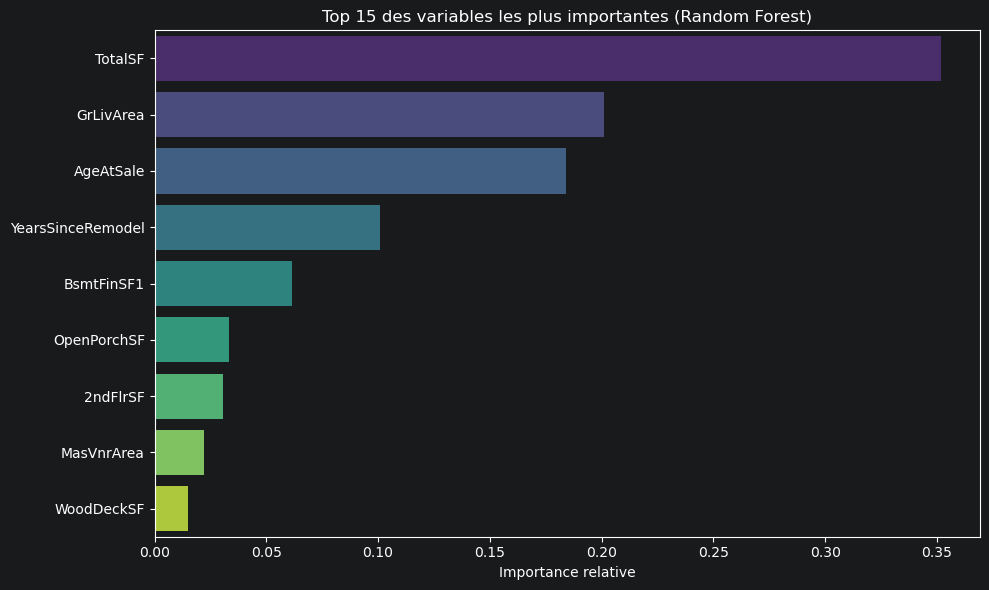

In [8]:
# 5. IMPORTANCE DES VARIABLES (Adapté pour l'architecture unifiée)

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Les noms des variables à la sortie de l'encodeur sont tout simplement les originaux
feature_names = X_train_clean.columns

# 2. Le Lasso a filtré des variables : on récupère uniquement celles qui sont passées
lasso_mask = best_m3_pipeline.named_steps['selector'].get_support()
selected_feature_names = feature_names[lasso_mask]

# 3. Récupération des scores d'importance calculés par le Random Forest
importances = best_m3_pipeline.named_steps['rf'].feature_importances_

# 4. Création d'un tableau propre
importance_df = pd.DataFrame({
    'Variable': selected_feature_names,
    'Importance': importances
})

# 5. Tri et sélection du Top 15 (Plus besoin de nettoyer avec regex !)
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15)

# 6. Affichage du graphique final
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Variable', palette='viridis')
plt.title('Top 15 des variables les plus importantes (Random Forest)')
plt.xlabel('Importance relative')
plt.ylabel('')
plt.tight_layout()
plt.show()